# Notebook 05a — Classical Unsupervised Baselines
## K-Means · Otsu Thresholding · SLIC+GrabCut

**Project:** MoE-RenalSAM-CG  
**Author:** Ashraful Kabir, BRAC University  
**Purpose:** Fully unsupervised segmentation baselines — no training, no prompts, no annotations used during inference.  
**Evaluation:** Expert RenSeg binary masks (Dice, IoU, HD95, Precision, Recall, F1) on **test split only**.

---
### What this notebook does
| Method | Strategy | Parameters |
|---|---|---|
| K-Means | Cluster CT pixels into k=3, pick pathology cluster by intensity | k=3, tries=10 |
| Otsu | Global thresholding + connected components + area filter | auto threshold |
| SLIC + GrabCut | Superpixel oversegment → GrabCut with center seed | n_segments=200 |

> **KEY RULE:** Expert masks are used **ONLY** for evaluation. Never during inference.

In [1]:
pip install tqdm scikit-image scikit-learn scipy Pillow opencv-python matplotlib pandas numpy

Note: you may need to restart the kernel to use updated packages.


## Section 1 — Imports & Paths

In [2]:
import os
import json
import time
import warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from scipy import ndimage as ndi
from scipy.ndimage import distance_transform_edt
from skimage.segmentation import slic
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from sklearn.cluster import MiniBatchKMeans

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Project root ─────────────────────────────────────────────────────────────
PROJECT_ROOT = Path(r'D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG')

KAGGLE_ROOT  = PROJECT_ROOT / 'data' / 'raw' / 'kaggle'
MASKS_ROOT   = PROJECT_ROOT / 'data' / 'processed' / 'renseg_masks'
SPLITS_DIR   = PROJECT_ROOT / 'data' / 'splits'
RESULTS_DIR  = PROJECT_ROOT / 'data' / 'processed' / 'reports' / 'baselines_classical'
PREDS_DIR    = PROJECT_ROOT / 'data' / 'processed' / 'predictions' / 'classical'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
for method in ['kmeans', 'otsu', 'grabcut']:
    for cls in ['Normal', 'Tumor', 'Stone']:
        (PREDS_DIR / method / cls).mkdir(parents=True, exist_ok=True)

CLASSES = ['Normal', 'Tumor', 'Stone']
PIXEL_SPACING_MM = 0.5  # assumption for HD95 in mm

print('✅ Imports OK')
print(f'   Project root : {PROJECT_ROOT}')
print(f'   Results dir  : {RESULTS_DIR}')
print(f'   Preds dir    : {PREDS_DIR}')

✅ Imports OK
   Project root : D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG
   Results dir  : D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG\data\processed\reports\baselines_classical
   Preds dir    : D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG\data\processed\predictions\classical


## Section 2 — Load Test Manifest

In [4]:
# ── Load Test Manifest and Column name patch ──────────────────────────────────
test_csv = SPLITS_DIR / 'test_manifest.csv'
test_df = pd.read_csv(test_csv)
# Actual manifest columns: image_path, class_name, stem, expert_mask_path

if 'class_name' in test_df.columns:
    test_df = test_df.rename(columns={'class_name': 'class'})

# Add has_expert_mask column if not present
if 'has_expert_mask' not in test_df.columns:
    test_df['has_expert_mask'] = test_df['expert_mask_path'].apply(
        lambda p: (PROJECT_ROOT / p).exists() if pd.notna(p) else False
    )

print(f'Total test images: {len(test_df)}')
print(test_df['class'].value_counts().to_string())
test_df.head(3)


Total test images: 1749
class
Normal    1016
Tumor      457
Stone      276


,image_path,class,stem,expert_mask_path,has_expert_mask
0,data\raw\kaggle\Normal\Normal- (3064).jpg,Normal,Normal- (3064),data\processed\renseg_masks\Normal\Normal- (30...,True
1,data\raw\kaggle\Normal\Normal- (581).jpg,Normal,Normal- (581),data\processed\renseg_masks\Normal\Normal- (58...,True
2,data\raw\kaggle\Normal\Normal- (1028).jpg,Normal,Normal- (1028),data\processed\renseg_masks\Normal\Normal- (10...,True


## Section 3 — Metrics

In [5]:
def compute_metrics(pred, gt, pixel_spacing_mm=0.5):
    p = (pred > 0).astype(bool).ravel()
    g = (gt   > 0).astype(bool).ravel()

    # Both empty → perfect prediction (especially for Normal class)
    if not p.any() and not g.any():
        return {'dice':1.0,'iou':1.0,'hd95':0.0,
                'precision':1.0,'recall':1.0,'f1':1.0}

    tp = np.logical_and(p,  g).sum()
    fp = np.logical_and(p, ~g).sum()
    fn = np.logical_and(~p, g).sum()

    dice      = (2*tp) / (2*tp + fp + fn + 1e-8)
    iou       = tp / (tp + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = (2*precision*recall) / (precision + recall + 1e-8)

    pred_2d = (pred > 0)
    gt_2d   = (gt   > 0)
    if pred_2d.any() and gt_2d.any():
        dt_pred  = distance_transform_edt(~pred_2d) * pixel_spacing_mm
        dt_gt    = distance_transform_edt(~gt_2d)   * pixel_spacing_mm
        hd95     = float(np.percentile(
                       np.concatenate([dt_gt[pred_2d], dt_pred[gt_2d]]), 95))
    else:
        hd95 = float(np.sqrt(pred_2d.shape[0]**2 + pred_2d.shape[1]**2) * pixel_spacing_mm)

    return {
        'dice':      round(float(dice),      4),
        'iou':       round(float(iou),       4),
        'hd95':      round(float(hd95),      4),
        'precision': round(float(precision), 4),
        'recall':    round(float(recall),    4),
        'f1':        round(float(f1),        4),
    }

def summarise_results(records: list, method_name: str) -> pd.DataFrame:
    """Aggregate per-image records to per-class + macro summary."""
    df = pd.DataFrame(records)
    metric_cols = ['dice', 'iou', 'hd95', 'precision', 'recall', 'f1']

    rows = []
    for cls in CLASSES:
        sub = df[df['class'] == cls]
        row = {'method': method_name, 'class': cls, 'n': len(sub)}
        for m in metric_cols:
            row[f'{m}_mean'] = round(sub[m].mean(), 4)
            row[f'{m}_std']  = round(sub[m].std(),  4)
        rows.append(row)

    # Macro average (exclude HD95 from simple avg — use per-class mean)
    macro = {'method': method_name, 'class': 'MACRO', 'n': len(df)}
    for m in metric_cols:
        col = f'{m}_mean'
        macro[f'{m}_mean'] = round(sum(r[col] for r in rows) / len(CLASSES), 4)
        macro[f'{m}_std']  = '—'
    rows.append(macro)

    return pd.DataFrame(rows)


print('✅ Metric functions defined')

✅ Metric functions defined


In [6]:
def extract_body_mask(gray: np.ndarray) -> np.ndarray:
    """
    Creates a coarse patient body mask by removing:
    - Pure black background (air outside patient)
    - Scan table / bed (thin horizontal bright band at bottom)
    Returns a uint8 binary mask (255 = inside body).
    """
    h, w = gray.shape

    # Threshold out pure background (air = very dark)
    _, body = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

    # Morphological closing to fill body interior
    kernel = np.ones((15, 15), np.uint8)
    body   = cv2.morphologyEx(body, cv2.MORPH_CLOSE, kernel, iterations=4)

    # Keep only the largest connected component (the patient body)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(body, 8)
    if num_labels > 1:
        largest = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1
        body    = ((labels == largest) * 255).astype(np.uint8)

    # Remove bottom 8% of image (scan table region)
    table_row = int(h * 0.92)
    body[table_row:, :] = 0

    return body

## Section 4 — Preprocessing Utilities

In [7]:
def load_image_gray(img_path: Path) -> np.ndarray:
    """Load JPEG as uint8 grayscale."""
    img = np.array(Image.open(img_path).convert('L'))
    return img


def load_image_rgb(img_path: Path) -> np.ndarray:
    """Load JPEG as uint8 RGB."""
    img = np.array(Image.open(img_path).convert('RGB'))
    return img


def load_gt_mask(mask_path: Path) -> np.ndarray:
    """Load binary GT mask as uint8 (0 or 255)."""
    mask = np.array(Image.open(mask_path).convert('L'))
    return (mask > 127).astype(np.uint8) * 255


def get_kaggle_path(row: pd.Series) -> Path:
    # image_path is already a relative path from project root
    return PROJECT_ROOT / row['image_path']

def get_mask_path(row: pd.Series) -> Path:
    # expert_mask_path is already a relative path from project root
    return PROJECT_ROOT / row['expert_mask_path']


def post_process_mask(mask: np.ndarray, class_name: str,
                      min_area_frac: float = 0.001) -> np.ndarray:
    """
    Post-process a raw binary prediction:
    - Remove tiny connected components (noise)
    - Keep only the largest blob for Tumor
    - For Stone: keep components within expected size range
    - For Normal: force empty mask (model should predict nothing)
    """
    if class_name == 'Normal':
        return np.zeros_like(mask)

    h, w = mask.shape
    total_pixels = h * w
    min_area = int(total_pixels * min_area_frac)

    # Label connected components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask.astype(np.uint8), connectivity=8
    )
    if num_labels <= 1:
        return np.zeros_like(mask)

    areas = stats[1:, cv2.CC_STAT_AREA]  # skip background (label 0)

    if class_name == 'Tumor':
        # Keep only the single largest component
        largest_label = np.argmax(areas) + 1
        out = np.zeros_like(mask)
        out[labels == largest_label] = 255
        return out

    if class_name == 'Stone':
        # Keep components within area bounds
        STONE_MIN = 50
        STONE_MAX = int(total_pixels * 0.05)  # stones are small
        out = np.zeros_like(mask)
        for i, area in enumerate(areas):
            if STONE_MIN <= area <= STONE_MAX:
                out[labels == (i + 1)] = 255
        if out.sum() == 0 and len(areas) > 0:
            # Fallback: keep largest if nothing passes filter
            largest_label = np.argmax(areas) + 1
            out[labels == largest_label] = 255
        return out

    return mask


print('✅ Preprocessing utilities defined')

✅ Preprocessing utilities defined


## Section 5 — Method 1: K-Means Clustering

**Strategy:**
- Convert CT image to grayscale + CLAHE enhanced
- Cluster pixels into k=3 groups using MiniBatchKMeans
- Select the pathology cluster using class-specific intensity heuristics:
  - **Tumor**: Brightest mid-range cluster (soft tissue HU)
  - **Stone**: Brightest cluster (calcification HU, very high intensity)
  - **Normal**: Always predict empty mask

In [8]:
def kmeans_segment(gray: np.ndarray, class_name: str,
                   k: int = 5, n_init: int = 5) -> np.ndarray:
    h, w = gray.shape

    if class_name == 'Normal':
        return np.zeros((h, w), dtype=np.uint8)

    # ── Step 1: Body mask — exclude background + table ───────────────────
    body_mask = extract_body_mask(gray)
    
    # ── Step 2: CLAHE on body pixels only ────────────────────────────────
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    enhanced[body_mask == 0] = 0   # zero out non-body pixels

    # ── Step 3: Cluster ONLY body pixels ────────────────────────────────
    body_coords = np.where(body_mask > 0)
    body_pixels = enhanced[body_coords].reshape(-1, 1).astype(np.float32)

    if len(body_pixels) < k:
        return np.zeros((h, w), dtype=np.uint8)

    kmeans = MiniBatchKMeans(n_clusters=k, n_init=n_init,
                             random_state=SEED, max_iter=300)
    cluster_ids = kmeans.fit_predict(body_pixels)
    centers     = kmeans.cluster_centers_.ravel()

    # Map back to image
    label_map = np.full((h, w), -1, dtype=np.int32)
    label_map[body_coords] = cluster_ids

    sorted_by_intensity = np.argsort(centers)  # low → high

    if class_name == 'Stone':
        # Stones = calcification = absolute brightest cluster
        # But restrict to small-area clusters only
        target = sorted_by_intensity[-1]
        mask   = ((label_map == target) * 255).astype(np.uint8)

        # If that cluster is too large (>5% body area) → likely bone not stone
        body_area = (body_mask > 0).sum()
        if (mask > 0).sum() > 0.05 * body_area:
            # Fall back: pick brightest cluster whose area < 5% body
            for idx in reversed(sorted_by_intensity):
                candidate = ((label_map == idx) * 255).astype(np.uint8)
                if (candidate > 0).sum() < 0.05 * body_area:
                    mask = candidate
                    break

    elif class_name == 'Tumor':
        # Tumors = soft tissue mass = mid-to-upper intensity
        # NOT the brightest (bone) and NOT the darkest (soft tissue bg)
        # Use the 2nd or 3rd brightest cluster; avoid top-1 (bone) and bottom-2 (air/fat)
        
        best_mask  = None
        best_score = -1

        # Evaluate candidates: 2nd brightest to 3rd brightest
        candidates = sorted_by_intensity[-3:-1]  # skip top-1 (bone)

        for idx in candidates:
            candidate = ((label_map == idx) * 255).astype(np.uint8)
            area_frac = (candidate > 0).sum() / (h * w)

            # Tumor expected area: 1% to 20% of full image
            if 0.01 < area_frac < 0.20:
                # Prefer cluster closer to image center (kidneys are central)
                cy, cx = np.where(candidate > 0)
                if len(cy) == 0:
                    continue
                centroid_y = cy.mean() / h
                centroid_x = cx.mean() / w
                # Score: penalise distance from center
                center_dist = abs(centroid_x - 0.5) + abs(centroid_y - 0.5)
                score = area_frac - center_dist * 0.5
                if score > best_score:
                    best_score = score
                    best_mask  = candidate

        if best_mask is None:
            # Fallback: 2nd brightest regardless of area
            target    = sorted_by_intensity[-2]
            best_mask = ((label_map == target) * 255).astype(np.uint8)

        mask = best_mask

    return mask


def post_process_mask(mask: np.ndarray, class_name: str) -> np.ndarray:
    if class_name == 'Normal':
        return np.zeros_like(mask)

    h, w         = mask.shape
    total_pixels = h * w

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask.astype(np.uint8), connectivity=8)
    if num_labels <= 1:
        return np.zeros_like(mask)

    areas = stats[1:, cv2.CC_STAT_AREA]

    if class_name == 'Tumor':
        # Keep only largest blob, but cap at 20% of image
        largest_label = np.argmax(areas) + 1
        out = np.zeros_like(mask)
        if areas[largest_label - 1] < 0.20 * total_pixels:
            out[labels == largest_label] = 255
        else:
            # Largest is too big (likely whole-body segment) → second largest
            sorted_labels = np.argsort(areas)[::-1]
            for lbl_idx in sorted_labels:
                if areas[lbl_idx] < 0.20 * total_pixels:
                    out[labels == (lbl_idx + 1)] = 255
                    break
        return out

    if class_name == 'Stone':
        # Stones: very small bright dots — aggressive area filter
        STONE_MIN = 20
        STONE_MAX = int(total_pixels * 0.02)  # max 2% of image
        out = np.zeros_like(mask)
        valid = [(i, a) for i, a in enumerate(areas)
                 if STONE_MIN <= a <= STONE_MAX]
        if valid:
            for i, _ in valid:
                out[labels == (i + 1)] = 255
        else:
            # Nothing passed → keep smallest component as best guess
            smallest = np.argmin(areas)
            out[labels == (smallest + 1)] = 255
        return out

    return mask

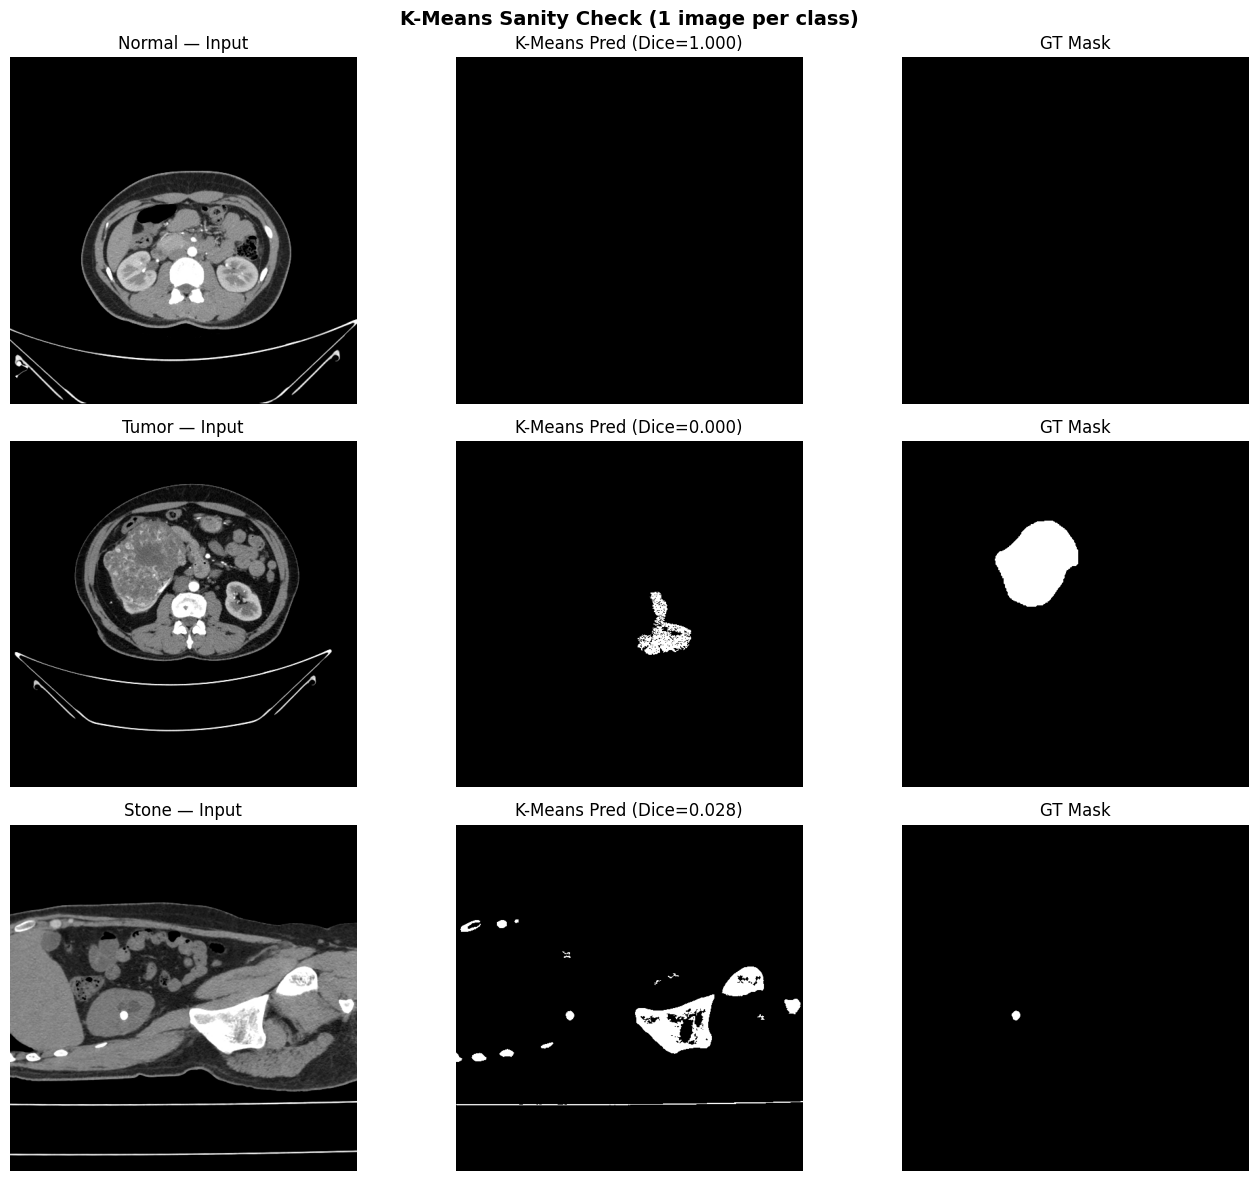

✅ Sanity check complete


In [9]:
# ── Quick sanity check on one image per class ─────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle('K-Means Sanity Check (1 image per class)', fontsize=14, fontweight='bold')

for row_idx, cls in enumerate(CLASSES):
    sample = test_df[test_df['class'] == cls].iloc[0]
    img_path  = get_kaggle_path(sample)
    mask_path = get_mask_path(sample)

    gray = load_image_gray(img_path)
    gt   = load_gt_mask(mask_path)

    raw_pred = kmeans_segment(gray, cls)
    pred     = post_process_mask(raw_pred, cls)

    metrics = compute_metrics(pred, gt)

    axes[row_idx, 0].imshow(gray, cmap='gray')
    axes[row_idx, 0].set_title(f'{cls} — Input')
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(pred, cmap='gray')
    axes[row_idx, 1].set_title(f'K-Means Pred (Dice={metrics["dice"]:.3f})')
    axes[row_idx, 1].axis('off')

    axes[row_idx, 2].imshow(gt, cmap='gray')
    axes[row_idx, 2].set_title(f'GT Mask')
    axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'kmeans_sanity_check.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sanity check complete')

In [10]:
# ── Run K-Means on full test set ──────────────────────────────────────────
print('Running K-Means on full test set...')
kmeans_records = []
t0 = time.time()

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='K-Means'):
    img_path  = get_kaggle_path(row)
    mask_path = get_mask_path(row)

    gray = load_image_gray(img_path)
    gt   = load_gt_mask(mask_path)

    raw_pred = kmeans_segment(gray, row['class'])
    pred     = post_process_mask(raw_pred, row['class'])

    # Save prediction
    stem      = row['stem']
    save_path = PREDS_DIR / 'kmeans' / row['class'] / f'{stem}_pred.png'
    Image.fromarray(pred).save(save_path)

    metrics = compute_metrics(pred, gt, PIXEL_SPACING_MM)
    metrics['class'] = row['class']
    metrics['stem']  = row['stem']
    kmeans_records.append(metrics)

elapsed = time.time() - t0
print(f'\n✅ K-Means done in {elapsed:.1f}s ({elapsed/len(test_df)*1000:.1f} ms/image)')

kmeans_summary = summarise_results(kmeans_records, 'K-Means')
print('\n── K-Means Results ──')
print(kmeans_summary[['class', 'n', 'dice_mean', 'dice_std',
                        'iou_mean', 'hd95_mean', 'f1_mean']].to_string(index=False))

# Save
pd.DataFrame(kmeans_records).to_csv(RESULTS_DIR / 'kmeans_per_image.csv', index=False)
kmeans_summary.to_csv(RESULTS_DIR / 'kmeans_summary.csv', index=False)


Running K-Means on full test set...


K-Means: 100%|█████████████████████████████████████████████████████████████████████| 1749/1749 [04:05<00:00,  7.12it/s]


✅ K-Means done in 245.5s (140.4 ms/image)

── K-Means Results ──
 class    n  dice_mean dice_std  iou_mean  hd95_mean  f1_mean
Normal 1016     1.0000      0.0    1.0000     0.0000   1.0000
 Tumor  457     0.0864   0.1591    0.0538    84.2197   0.0864
 Stone  276     0.0384     0.05    0.0203   150.5058   0.0384
 MACRO 1749     0.3749        —    0.3580    78.2418   0.3749


## Section 6 — Method 2: Otsu Thresholding + Connected Components

**Strategy:**
- CLAHE → Gaussian blur → Otsu threshold
- Connected components analysis
- Class-specific area filtering
  - **Tumor**: Largest blob in expected area range
  - **Stone**: Small bright blobs (calcification HU)
  - **Normal**: Always empty mask

In [11]:
def otsu_segment(gray: np.ndarray, class_name: str) -> np.ndarray:
    """
    Otsu thresholding + connected component filtering.

    Applies CLAHE + Gaussian smoothing before thresholding.
    Then filters components by class-specific area expectations.
    """
    h, w = gray.shape

    if class_name == 'Normal':
        return np.zeros((h, w), dtype=np.uint8)

    # ── Preprocessing ────────────────────────────────────────────────────
    clahe     = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced  = clahe.apply(gray)
    blurred   = cv2.GaussianBlur(enhanced, (5, 5), 0)

    # ── Otsu threshold ───────────────────────────────────────────────────
    thresh_val, binary = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # ── Morphological cleaning ───────────────────────────────────────────
    if class_name == 'Tumor':
        # Close gaps in tumor blob
        kernel = np.ones((9, 9), np.uint8)
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
        binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  kernel, iterations=1)

    elif class_name == 'Stone':
        # Stones are tiny — minimal morphology
        kernel = np.ones((3, 3), np.uint8)
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=1)

    # ── Additional class-aware refinement ────────────────────────────────
    if class_name == 'Tumor':
        # For tumors: mask out very bright pixels (bones/stones) &
        # keep only moderate-to-high intensity regions
        bright_cutoff = int(np.percentile(enhanced[enhanced > 0], 95))
        too_bright    = (enhanced > bright_cutoff)
        binary[too_bright] = 0

    return binary


print('✅ Otsu function defined')

✅ Otsu function defined


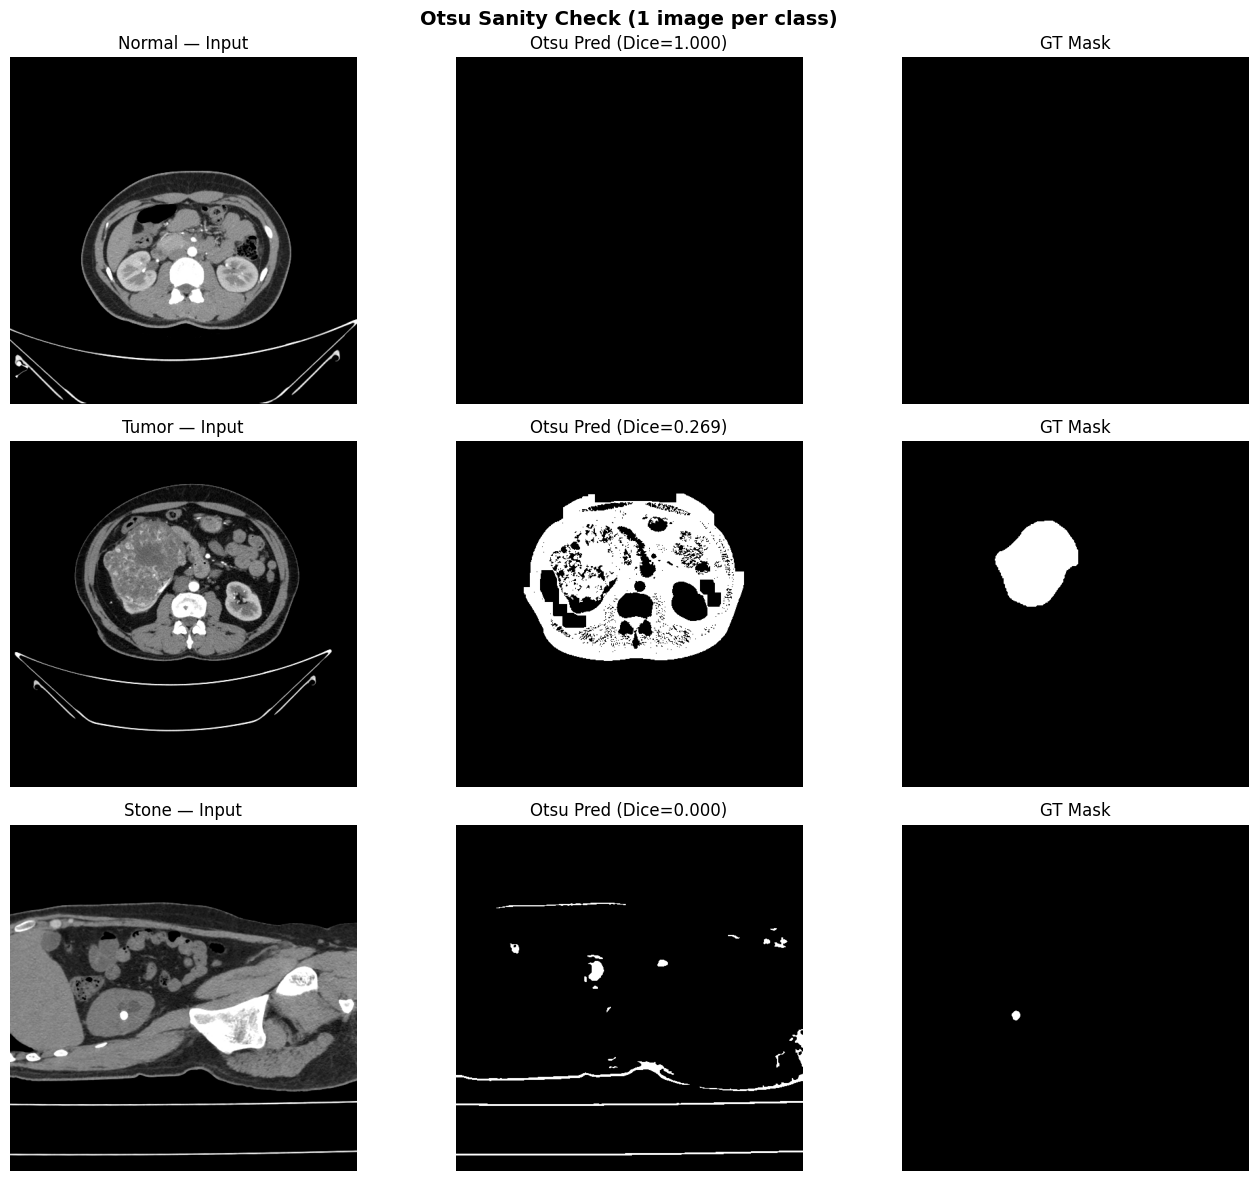

In [12]:
# ── Quick sanity check ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle('Otsu Sanity Check (1 image per class)', fontsize=14, fontweight='bold')

for row_idx, cls in enumerate(CLASSES):
    sample    = test_df[test_df['class'] == cls].iloc[0]
    img_path  = get_kaggle_path(sample)
    mask_path = get_mask_path(sample)

    gray = load_image_gray(img_path)
    gt   = load_gt_mask(mask_path)

    raw_pred = otsu_segment(gray, cls)
    pred     = post_process_mask(raw_pred, cls)
    metrics  = compute_metrics(pred, gt)

    axes[row_idx, 0].imshow(gray, cmap='gray')
    axes[row_idx, 0].set_title(f'{cls} — Input')
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(pred, cmap='gray')
    axes[row_idx, 1].set_title(f'Otsu Pred (Dice={metrics["dice"]:.3f})')
    axes[row_idx, 1].axis('off')

    axes[row_idx, 2].imshow(gt, cmap='gray')
    axes[row_idx, 2].set_title('GT Mask')
    axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'otsu_sanity_check.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── Run Otsu on full test set ─────────────────────────────────────────────
print('Running Otsu on full test set...')
otsu_records = []
t0 = time.time()

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Otsu'):
    img_path  = get_kaggle_path(row)
    mask_path = get_mask_path(row)

    gray = load_image_gray(img_path)
    gt   = load_gt_mask(mask_path)

    raw_pred = otsu_segment(gray, row['class'])
    pred     = post_process_mask(raw_pred, row['class'])

    stem      = row['stem']
    save_path = PREDS_DIR / 'otsu' / row['class'] / f'{stem}_pred.png'
    Image.fromarray(pred).save(save_path)

    metrics = compute_metrics(pred, gt, PIXEL_SPACING_MM)
    metrics['class'] = row['class']
    metrics['stem']  = row['stem']
    otsu_records.append(metrics)

elapsed = time.time() - t0
print(f'\n✅ Otsu done in {elapsed:.1f}s ({elapsed/len(test_df)*1000:.1f} ms/image)')

otsu_summary = summarise_results(otsu_records, 'Otsu')
print('\n── Otsu Results ──')
print(otsu_summary[['class', 'n', 'dice_mean', 'dice_std',
                      'iou_mean', 'hd95_mean', 'f1_mean']].to_string(index=False))

pd.DataFrame(otsu_records).to_csv(RESULTS_DIR / 'otsu_per_image.csv', index=False)
otsu_summary.to_csv(RESULTS_DIR / 'otsu_summary.csv', index=False)


Running Otsu on full test set...


Otsu: 100%|████████████████████████████████████████████████████████████████████████| 1749/1749 [00:24<00:00, 71.39it/s]


✅ Otsu done in 24.5s (14.0 ms/image)

── Otsu Results ──
 class    n  dice_mean dice_std  iou_mean  hd95_mean  f1_mean
Normal 1016     1.0000      0.0    1.0000     0.0000   1.0000
 Tumor  457     0.0419   0.0805    0.0233   141.0644   0.0419
 Stone  276     0.0106    0.021    0.0054   163.2222   0.0106
 MACRO 1749     0.3508        —    0.3429   101.4289   0.3508


## Section 7 — Method 3: SLIC Superpixels + GrabCut

**Strategy:**
- Oversegment image into SLIC superpixels (n=200)
- Find the central region (ROI seed) using image center or Otsu pre-mask centroid
- Run GrabCut with a tight foreground rectangle seeded from the superpixel centroid
- GrabCut iteratively refines using graph-cut energy minimization

This is stronger than pure Otsu because GrabCut models foreground/background appearance jointly.

In [15]:
def grabcut_segment(rgb: np.ndarray, class_name: str,
                    n_segments: int = 200, gc_iters: int = 10) -> np.ndarray:
    """
    SLIC superpixel oversegmentation + GrabCut refinement.

    1. SLIC superpixels to identify candidate regions.
    2. Use Otsu pre-mask to find seed bounding rectangle for GrabCut.
    3. GrabCut produces soft fg/bg labels → threshold to binary.
    4. Class-specific post-processing.
    """
    h, w = rgb.shape[:2]

    if class_name == 'Normal':
        return np.zeros((h, w), dtype=np.uint8)

    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

    # ── Step 1: SLIC superpixels ─────────────────────────────────────────
    segments = slic(rgb, n_segments=n_segments, compactness=10,
                    sigma=1, start_label=1)

    # ── Step 2: Seed rectangle from Otsu pre-mask ────────────────────────
    clahe    = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    blurred  = cv2.GaussianBlur(enhanced, (5, 5), 0)
    _, otsu_mask = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    if class_name == 'Stone':
        # Stones are bright — use high intensity pixels as seed
        high_thresh = int(np.percentile(enhanced[enhanced > 0], 90))
        seed_mask   = (enhanced > high_thresh).astype(np.uint8) * 255
    else:
        seed_mask = otsu_mask

    # Find bounding rect of seed region
    ys, xs = np.where(seed_mask > 0)
    if len(xs) == 0:
        # No seed found → fallback to center crop
        margin = 0.2
        x1 = int(w * margin)
        y1 = int(h * margin)
        bw = int(w * (1 - 2*margin))
        bh = int(h * (1 - 2*margin))
    else:
        padding = 10
        x1 = max(0, int(xs.min()) - padding)
        y1 = max(0, int(ys.min()) - padding)
        x2 = min(w, int(xs.max()) + padding)
        y2 = min(h, int(ys.max()) + padding)
        bw = x2 - x1
        bh = y2 - y1

    # Ensure valid rectangle
    bw = max(bw, 10)
    bh = max(bh, 10)
    x1 = min(x1, w - bw - 1)
    y1 = min(y1, h - bh - 1)
    rect = (x1, y1, bw, bh)

    # ── Step 3: GrabCut ──────────────────────────────────────────────────
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)
    gc_mask   = np.zeros((h, w), np.uint8)

    try:
        cv2.grabCut(
            rgb, gc_mask, rect,
            bgd_model, fgd_model,
            gc_iters, cv2.GC_INIT_WITH_RECT
        )
    except cv2.error:
        # GrabCut can fail on degenerate inputs — fallback to Otsu
        return otsu_segment(gray, class_name)

    # Combine probable and definite foreground
    fg_mask = np.where(
        (gc_mask == cv2.GC_FGD) | (gc_mask == cv2.GC_PR_FGD),
        255, 0
    ).astype(np.uint8)

    # ── Step 4: Superpixel-guided refinement ─────────────────────────────
    # For each superpixel, vote: if majority pixels are fg → entire SP is fg
    refined = np.zeros((h, w), dtype=np.uint8)
    for sp_id in np.unique(segments):
        sp_pixels  = segments == sp_id
        fg_ratio   = fg_mask[sp_pixels].mean() / 255.0
        if fg_ratio > 0.5:
            refined[sp_pixels] = 255

    return refined


print('✅ GrabCut function defined')

✅ GrabCut function defined


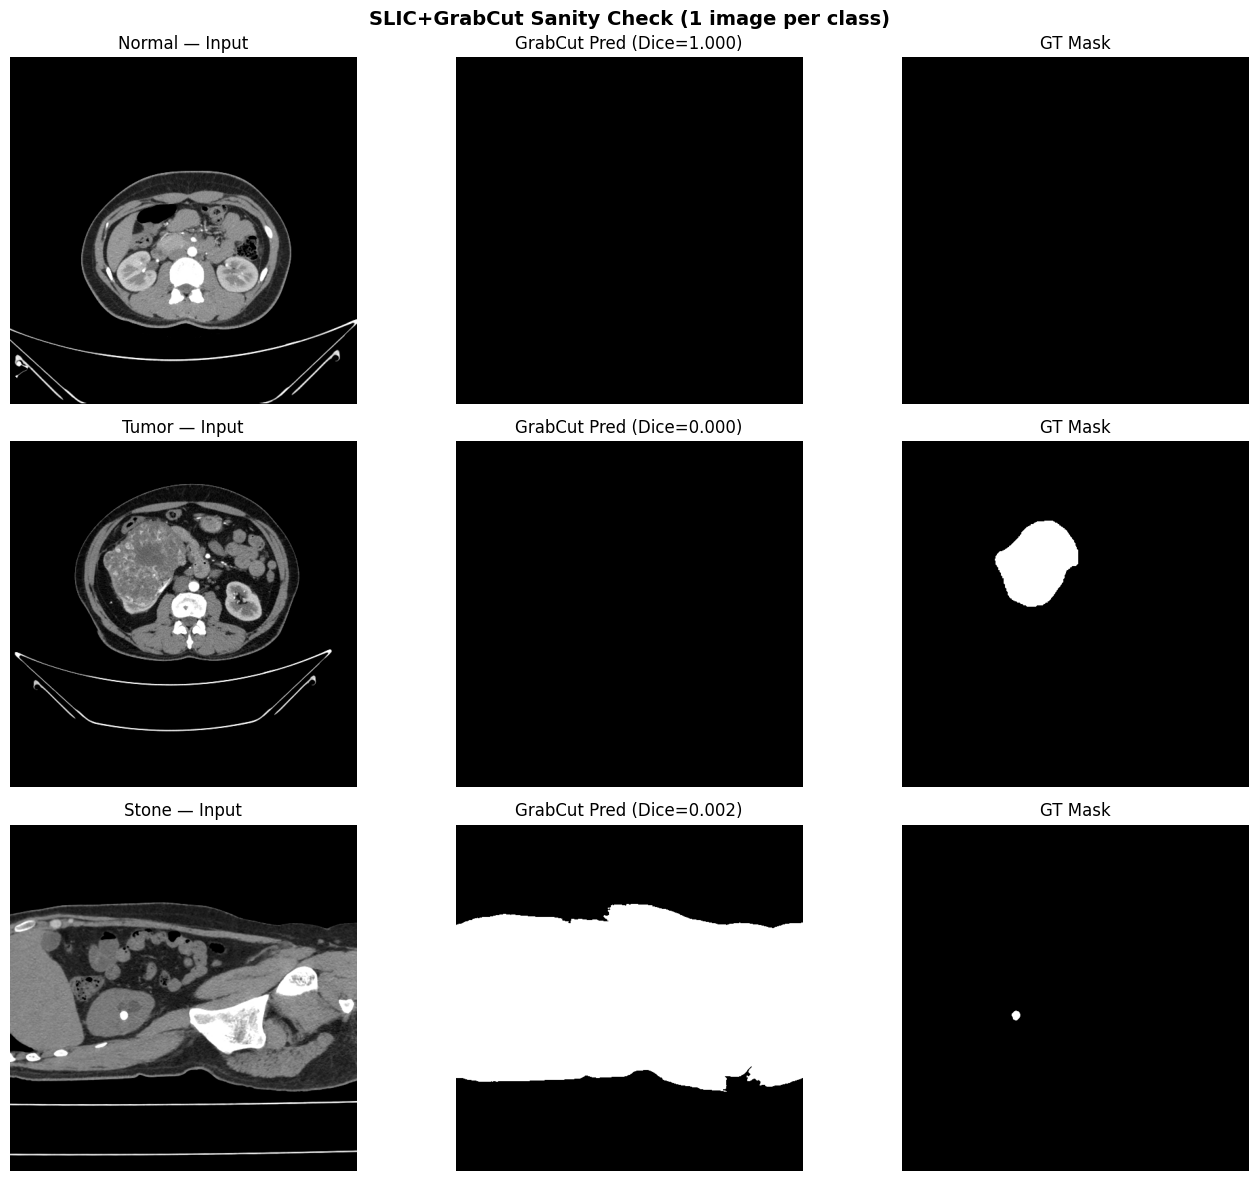

In [16]:
# ── Quick sanity check ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle('SLIC+GrabCut Sanity Check (1 image per class)', fontsize=14, fontweight='bold')

for row_idx, cls in enumerate(CLASSES):
    sample    = test_df[test_df['class'] == cls].iloc[0]
    img_path  = get_kaggle_path(sample)
    mask_path = get_mask_path(sample)

    rgb  = load_image_rgb(img_path)
    gt   = load_gt_mask(mask_path)

    raw_pred = grabcut_segment(rgb, cls)
    pred     = post_process_mask(raw_pred, cls)
    metrics  = compute_metrics(pred, gt)

    axes[row_idx, 0].imshow(rgb)
    axes[row_idx, 0].set_title(f'{cls} — Input')
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(pred, cmap='gray')
    axes[row_idx, 1].set_title(f'GrabCut Pred (Dice={metrics["dice"]:.3f})')
    axes[row_idx, 1].axis('off')

    axes[row_idx, 2].imshow(gt, cmap='gray')
    axes[row_idx, 2].set_title('GT Mask')
    axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'grabcut_sanity_check.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── Run GrabCut on full test set ──────────────────────────────────────────
print('Running SLIC+GrabCut on full test set...')
grabcut_records = []
t0 = time.time()

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='GrabCut'):
    img_path  = get_kaggle_path(row)
    mask_path = get_mask_path(row)

    rgb = load_image_rgb(img_path)
    gt  = load_gt_mask(mask_path)

    raw_pred = grabcut_segment(rgb, row['class'])
    pred     = post_process_mask(raw_pred, row['class'])

    stem      = row['stem']
    save_path = PREDS_DIR / 'grabcut' / row['class'] / f'{stem}_pred.png'
    Image.fromarray(pred).save(save_path)

    metrics = compute_metrics(pred, gt, PIXEL_SPACING_MM)
    metrics['class']    = row['class']
    metrics['stem'] = row['stem']
    grabcut_records.append(metrics)

elapsed = time.time() - t0
print(f'\n✅ GrabCut done in {elapsed:.1f}s ({elapsed/len(test_df)*1000:.1f} ms/image)')

grabcut_summary = summarise_results(grabcut_records, 'SLIC+GrabCut')
print('\n── SLIC+GrabCut Results ──')
print(grabcut_summary[['class', 'n', 'dice_mean', 'dice_std',
                         'iou_mean', 'hd95_mean', 'f1_mean']].to_string(index=False))

pd.DataFrame(grabcut_records).to_csv(RESULTS_DIR / 'grabcut_per_image.csv', index=False)
grabcut_summary.to_csv(RESULTS_DIR / 'grabcut_summary.csv', index=False)

Running SLIC+GrabCut on full test set...


GrabCut: 100%|█████████████████████████████████████████████████████████████████████| 1749/1749 [19:17<00:00,  1.51it/s]


✅ GrabCut done in 1157.2s (661.6 ms/image)

── SLIC+GrabCut Results ──
 class    n  dice_mean dice_std  iou_mean  hd95_mean  f1_mean
Normal 1016     1.0000      0.0    1.0000     0.0000   1.0000
 Tumor  457     0.0231   0.1052    0.0160   338.6789   0.0231
 Stone  276     0.0085   0.0199    0.0044   131.8824   0.0085
 MACRO 1749     0.3439        —    0.3401   156.8538   0.3439


## Section 8 — Combined Results Table

In [19]:
all_summaries = pd.concat([kmeans_summary, otsu_summary, grabcut_summary],
                           ignore_index=True)

# Pretty display
display_cols = ['method', 'class', 'n',
                'dice_mean', 'dice_std',
                'iou_mean',  'iou_std',
                'hd95_mean',
                'precision_mean', 'recall_mean', 'f1_mean']

print('\n' + '='*80)
print('  CLASSICAL UNSUPERVISED BASELINES — COMPLETE RESULTS')
print('='*80)
print(all_summaries[display_cols].to_string(index=False))
print('='*80)

# Save combined
all_summaries.to_csv(RESULTS_DIR / 'classical_baselines_summary.csv', index=False)

# Also save as JSON for later aggregation with deep model results
results_json = {}
for method in ['K-Means', 'Otsu', 'SLIC+GrabCut']:
    macro = all_summaries[
        (all_summaries['method'] == method) &
        (all_summaries['class']  == 'MACRO')
    ].iloc[0]
    results_json[method] = {
        'dice':  macro['dice_mean'],
        'iou':   macro['iou_mean'],
        'hd95':  macro['hd95_mean'],
        'f1':    macro['f1_mean'],
    }

with open(RESULTS_DIR / 'classical_baselines_macro.json', 'w') as f:
    json.dump(results_json, f, indent=2)

print(f'\n✅ All results saved to: {RESULTS_DIR}')


  CLASSICAL UNSUPERVISED BASELINES — COMPLETE RESULTS
      method  class    n  dice_mean dice_std  iou_mean iou_std  hd95_mean  precision_mean  recall_mean  f1_mean
     K-Means Normal 1016     1.0000      0.0    1.0000     0.0     0.0000          1.0000       1.0000   1.0000
     K-Means  Tumor  457     0.0864   0.1591    0.0538  0.1041    84.2197          0.1012       0.0932   0.0864
     K-Means  Stone  276     0.0384     0.05    0.0203  0.0276   150.5058          0.0203       0.7506   0.0384
     K-Means  MACRO 1749     0.3749        —    0.3580       —    78.2418          0.3738       0.6146   0.3749
        Otsu Normal 1016     1.0000      0.0    1.0000     0.0     0.0000          1.0000       1.0000   1.0000
        Otsu  Tumor  457     0.0419   0.0805    0.0233  0.0458   141.0644          0.0269       0.1638   0.0419
        Otsu  Stone  276     0.0106    0.021    0.0054   0.011   163.2222          0.0056       0.3987   0.0106
        Otsu  MACRO 1749     0.3508        —    0

## Section 9 — Visualisation: Per-Class Metric Comparison

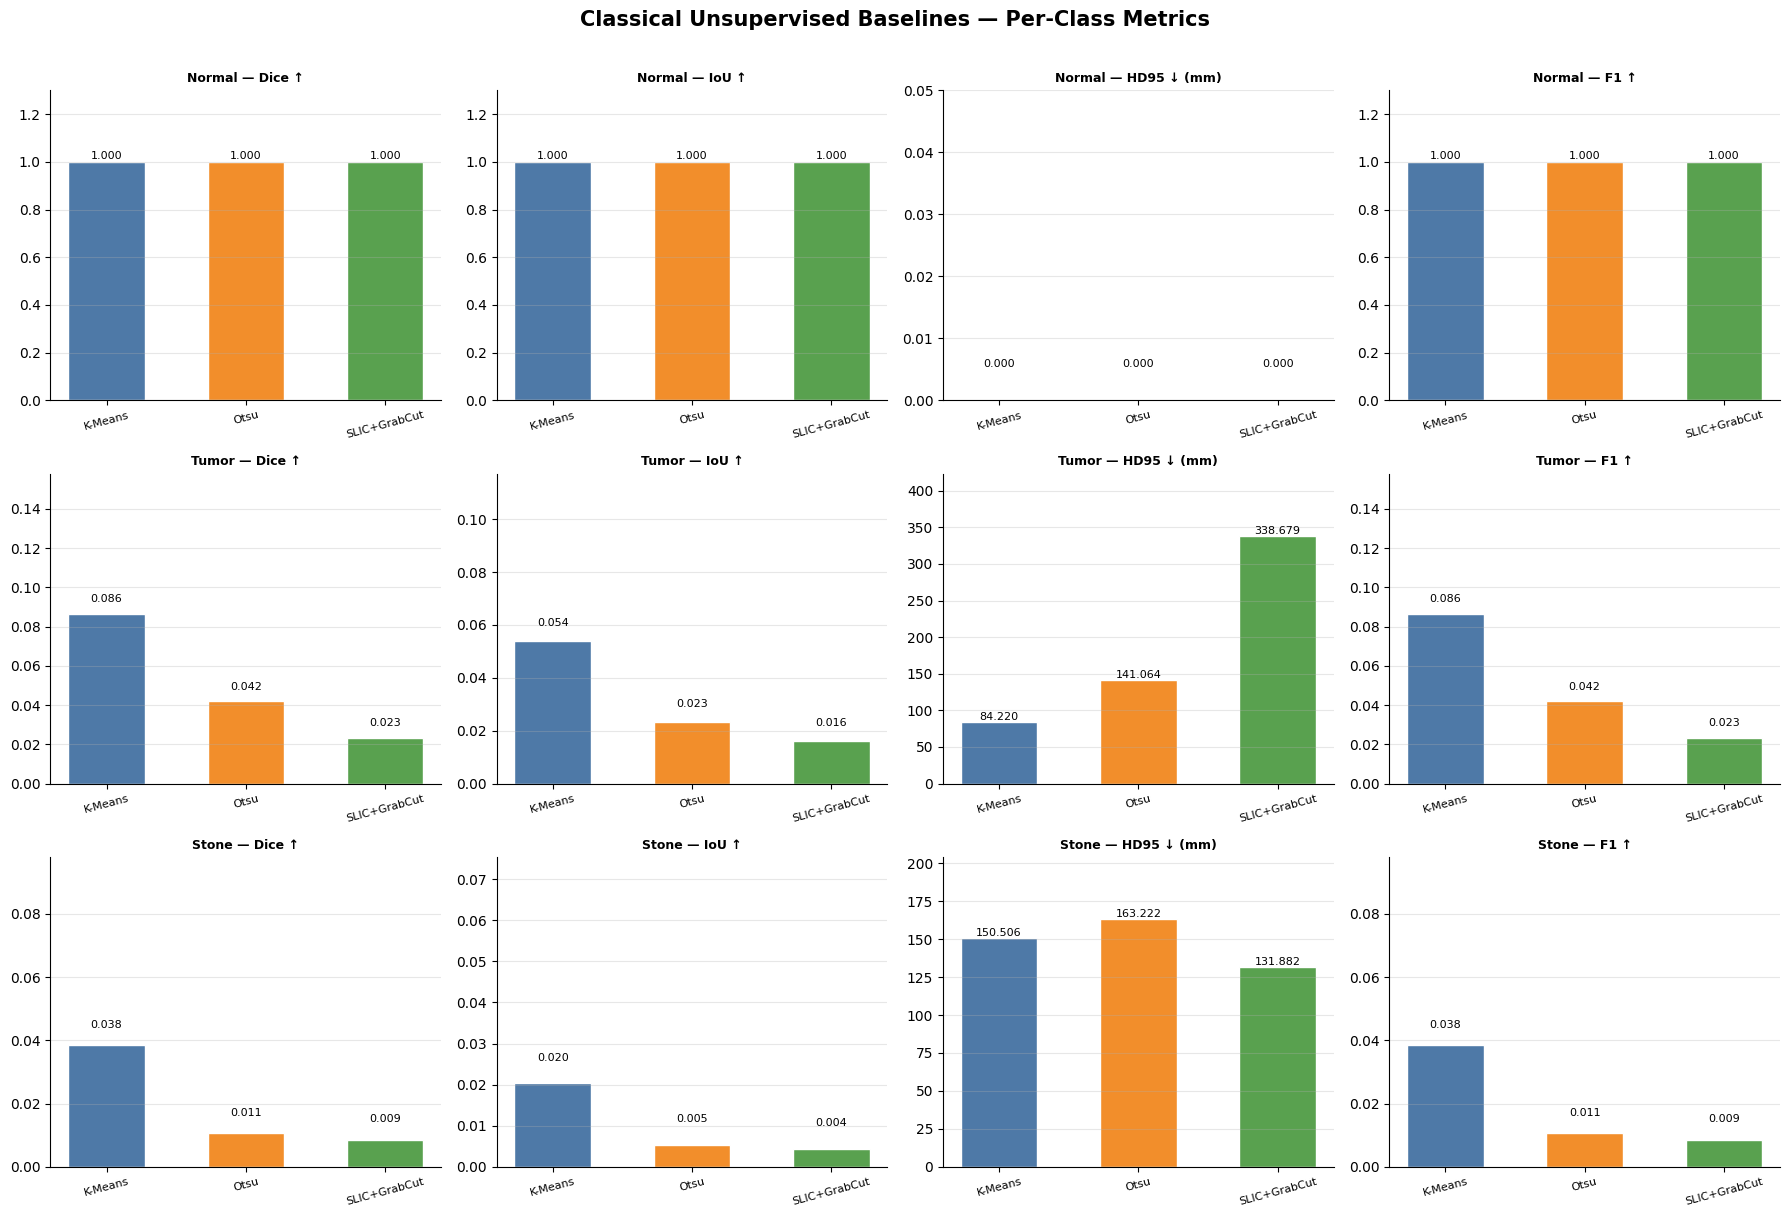

✅ Comparison figure saved


In [20]:
metrics_to_plot = ['dice_mean', 'iou_mean', 'hd95_mean', 'f1_mean']
metric_labels   = ['Dice ↑', 'IoU ↑', 'HD95 ↓ (mm)', 'F1 ↑']
methods         = ['K-Means', 'Otsu', 'SLIC+GrabCut']
colors          = ['#4e79a7', '#f28e2b', '#59a14f']

fig, axes = plt.subplots(len(CLASSES), len(metrics_to_plot),
                          figsize=(18, 12))
fig.suptitle('Classical Unsupervised Baselines — Per-Class Metrics',
             fontsize=15, fontweight='bold', y=1.01)

for row_idx, cls in enumerate(CLASSES):
    for col_idx, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
        ax     = axes[row_idx, col_idx]
        subset = all_summaries[
            (all_summaries['class']  == cls) &
            (all_summaries['method'].isin(methods))
        ]
        vals   = [subset[subset['method'] == m][metric].values[0] for m in methods]
        bars   = ax.bar(methods, vals, color=colors, edgecolor='white', width=0.55)

        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

        ax.set_title(f'{cls} — {label}', fontsize=9, fontweight='bold')
        ax.set_ylim(0, max(vals) * 1.25 + 0.05)
        ax.set_xticklabels(methods, rotation=15, fontsize=8)
        ax.grid(axis='y', alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'classical_baselines_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison figure saved')

## Section 10 — Qualitative Gallery (5 samples per class per method)

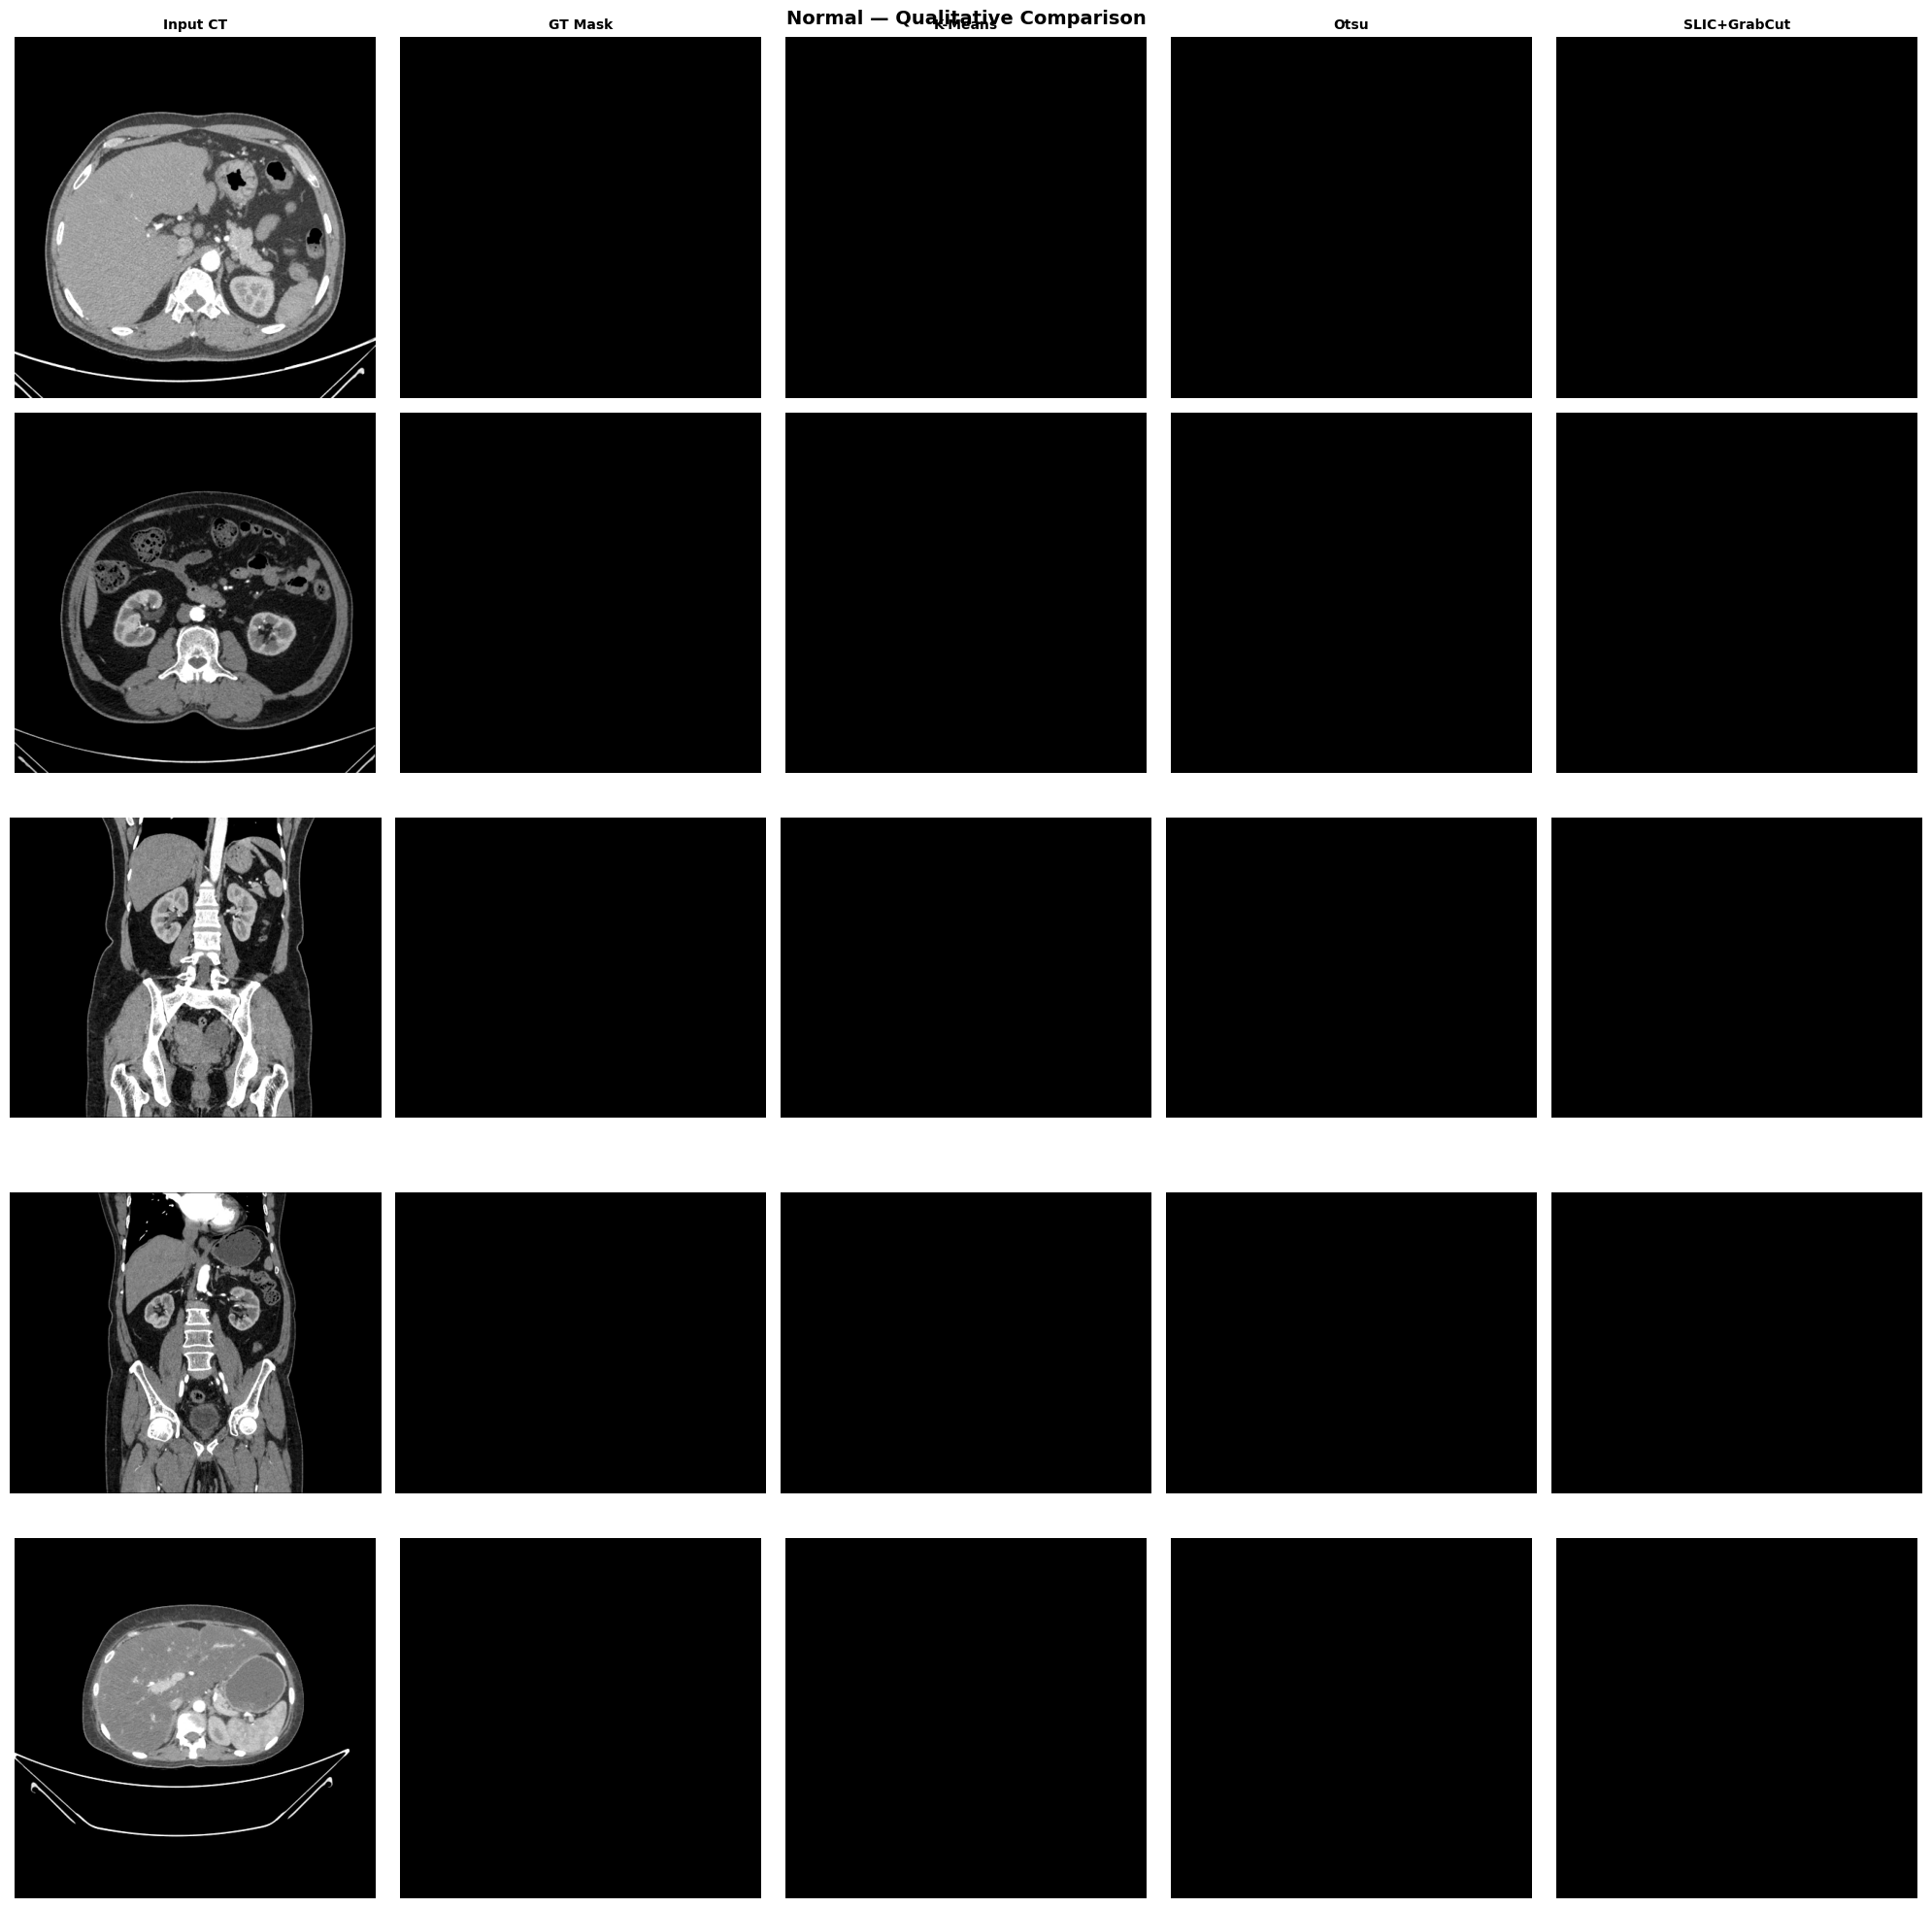

  ✅ Normal gallery saved


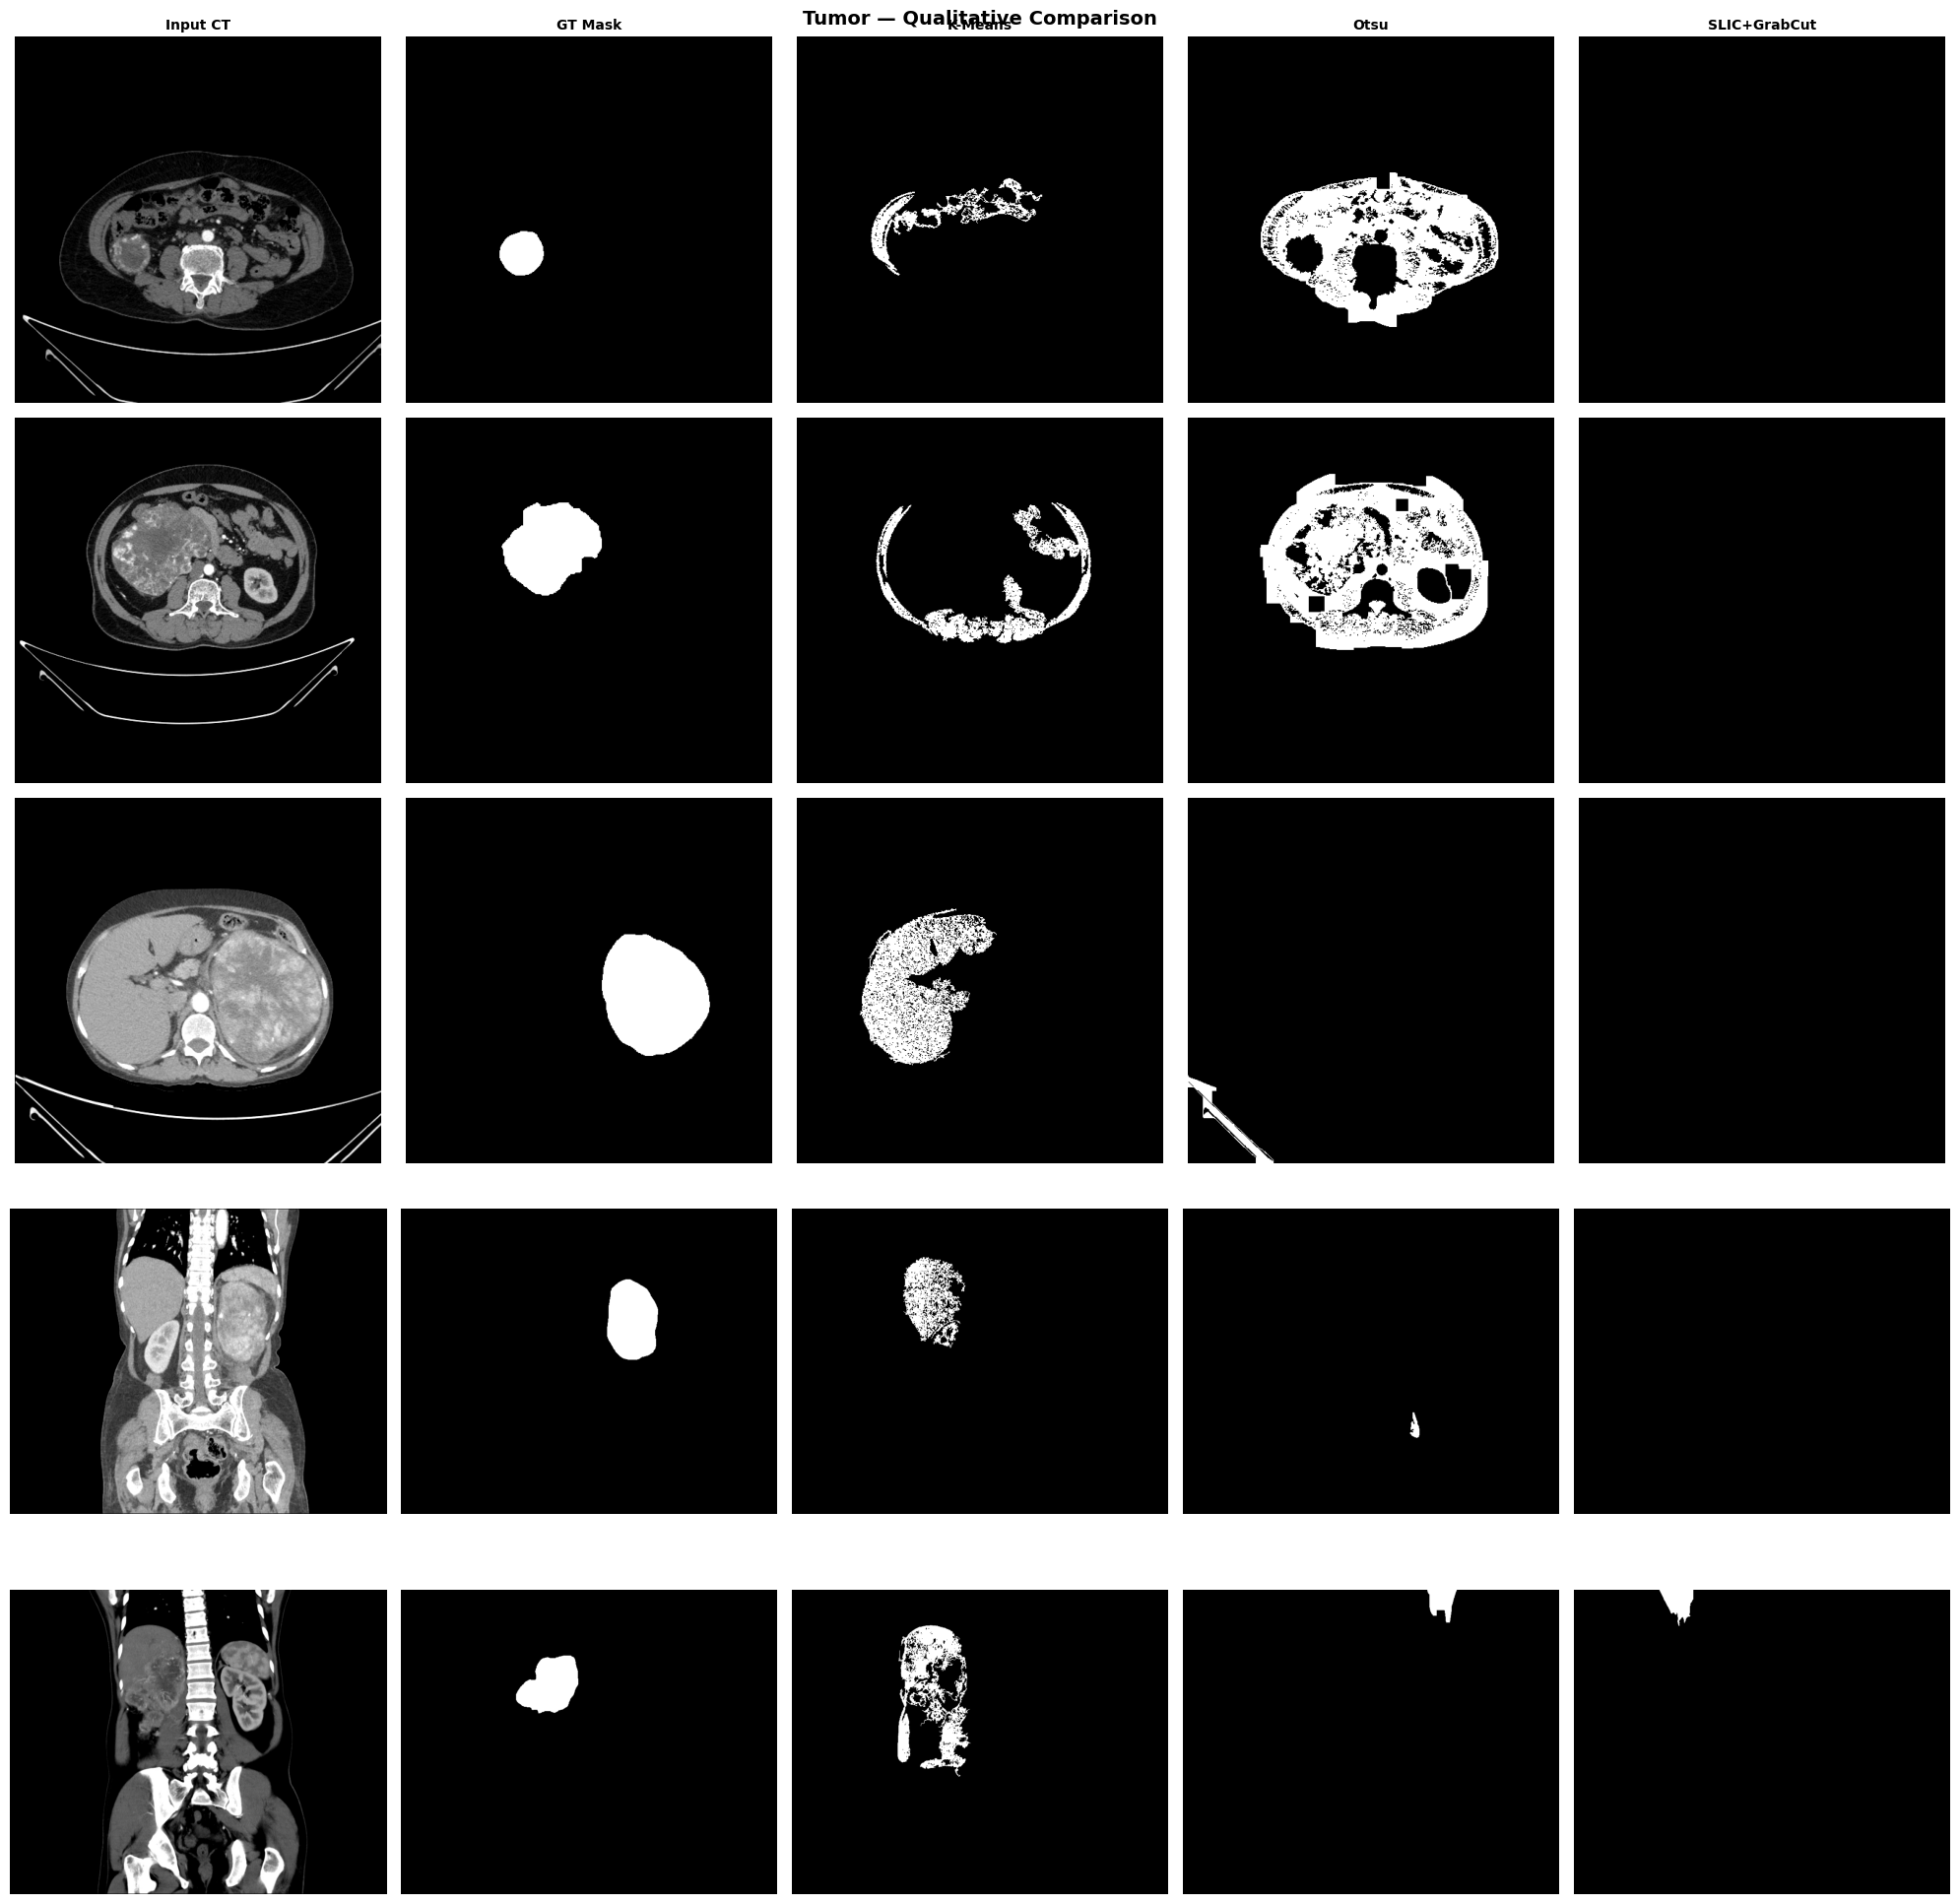

  ✅ Tumor gallery saved


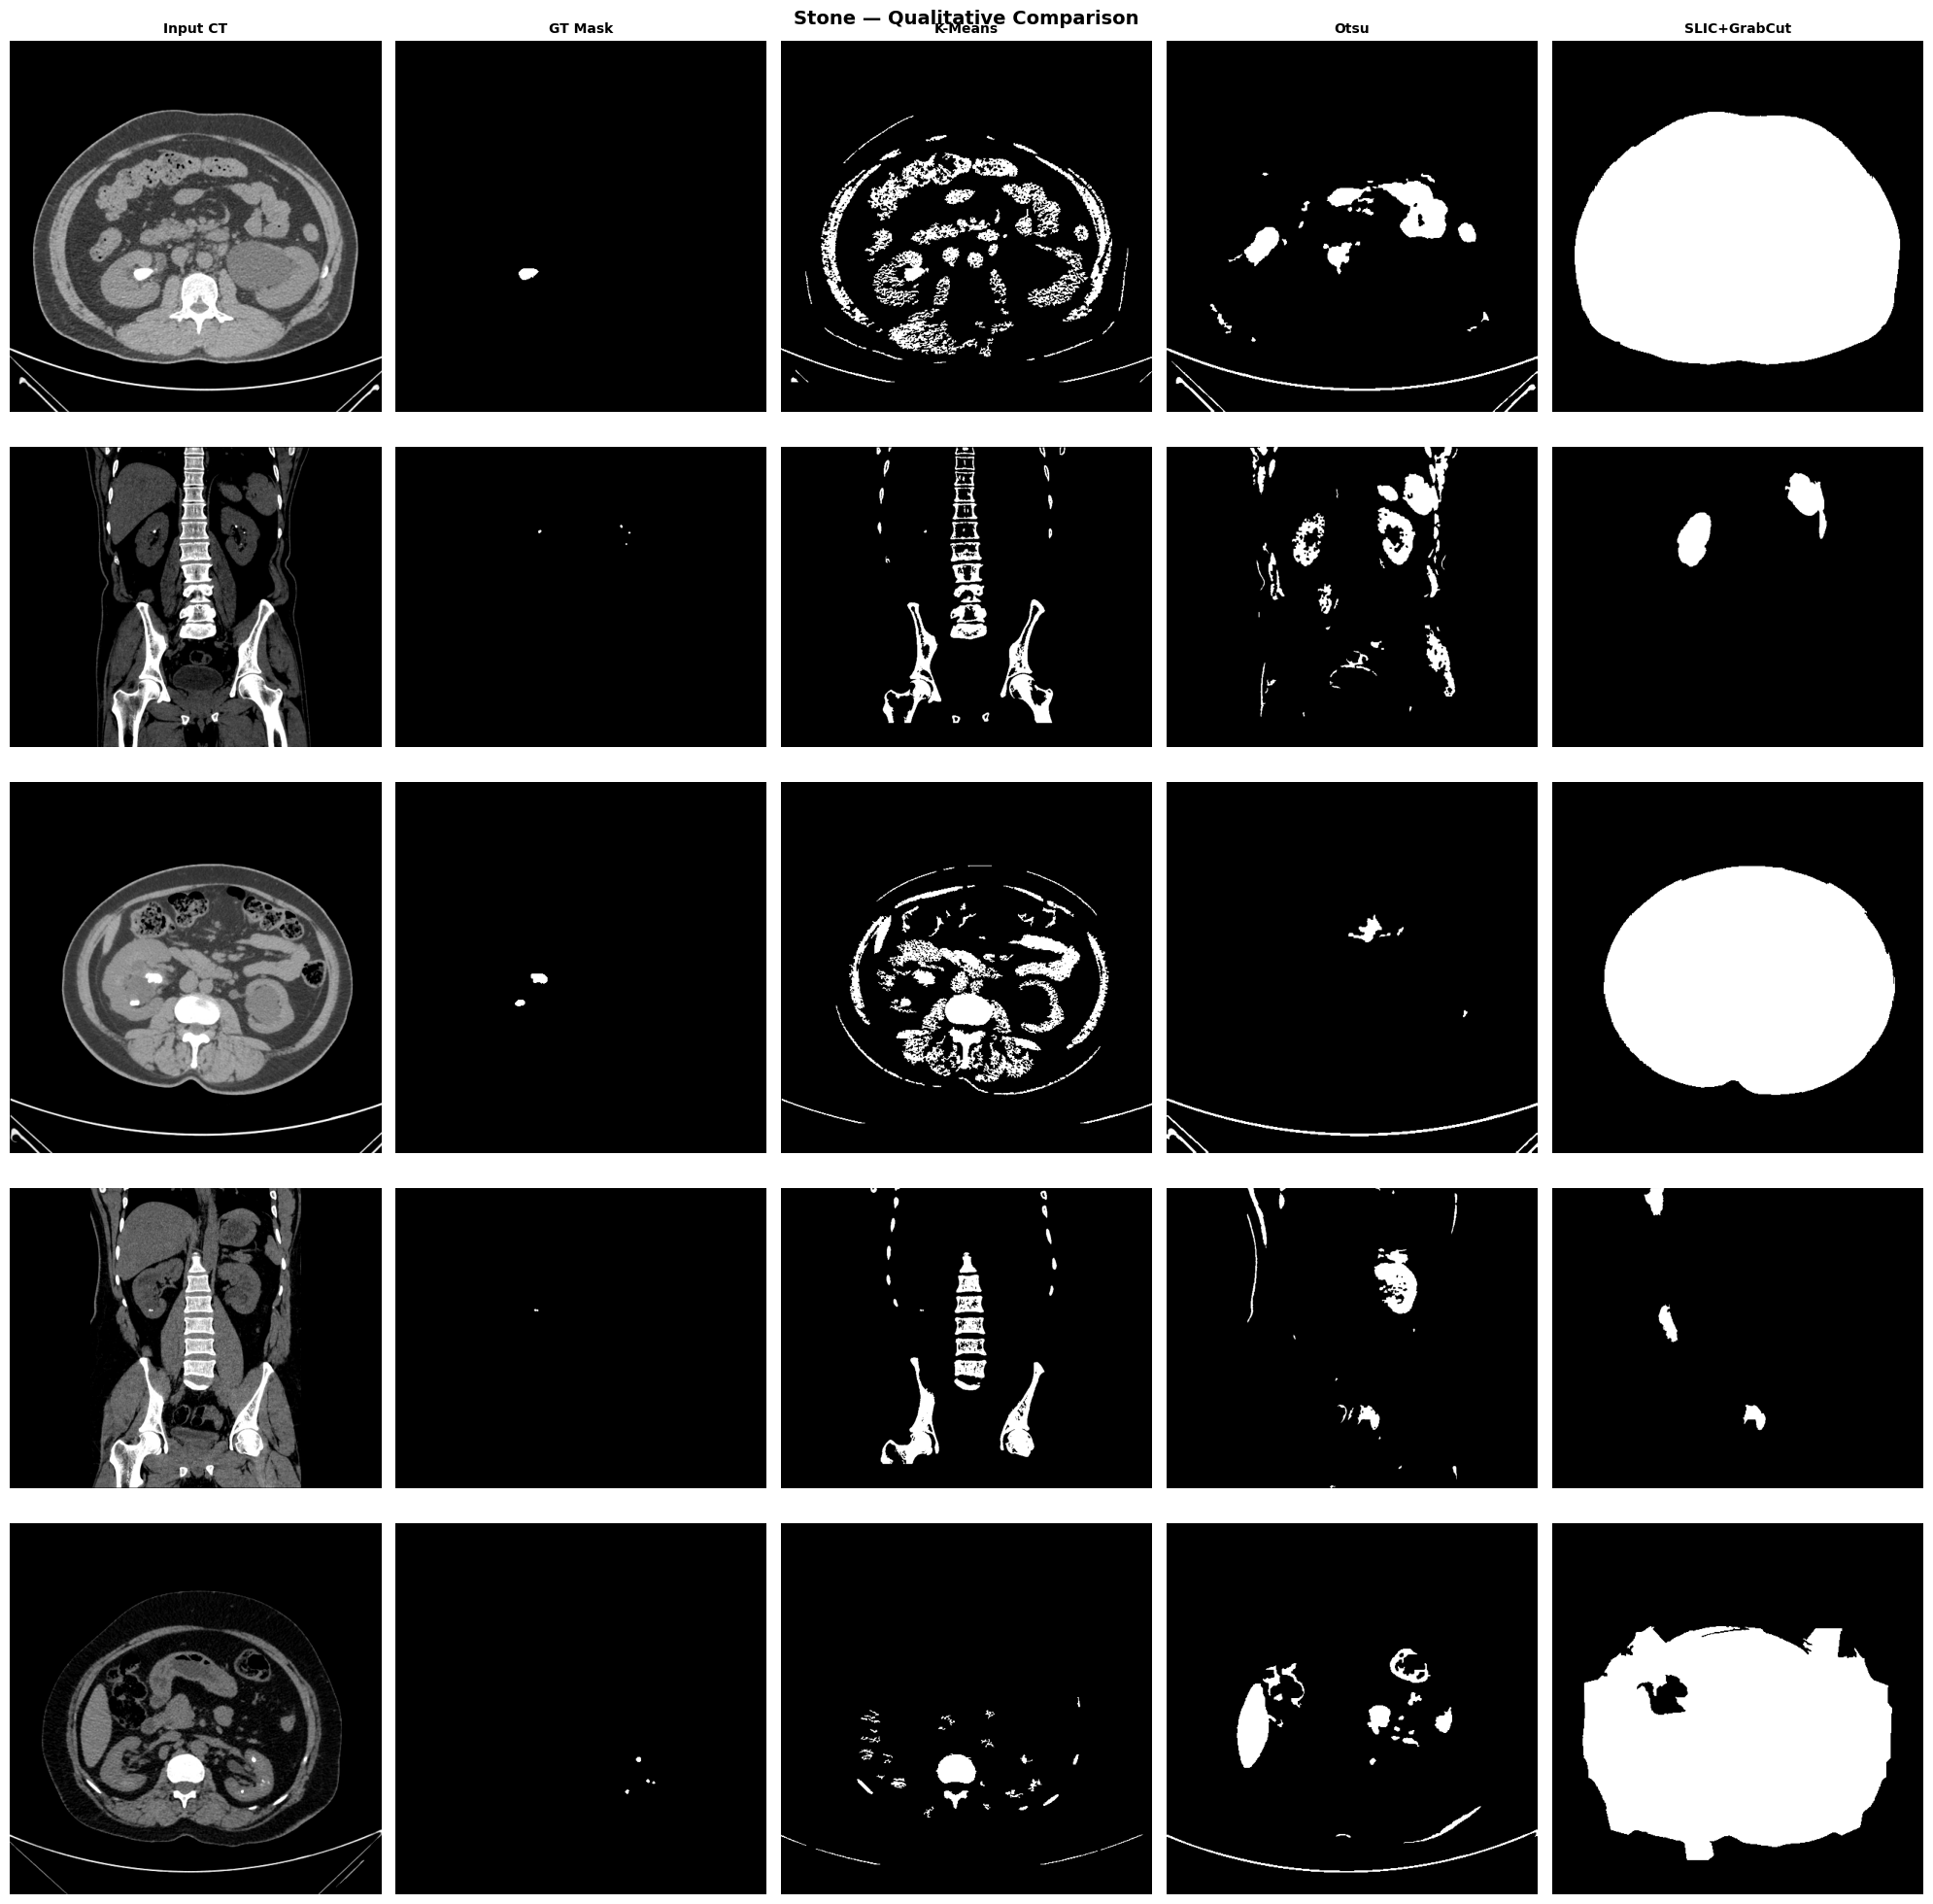

  ✅ Stone gallery saved

✅ All qualitative galleries saved


In [22]:
N_SAMPLES = 5

for cls in CLASSES:
    samples = test_df[test_df['class'] == cls].sample(
        min(N_SAMPLES, len(test_df[test_df['class'] == cls])),
        random_state=SEED
    )

    fig, axes = plt.subplots(
        N_SAMPLES, 5,
        figsize=(20, 4 * N_SAMPLES)
    )
    fig.suptitle(f'{cls} — Qualitative Comparison',
                 fontsize=14, fontweight='bold')

    col_titles = ['Input CT', 'GT Mask', 'K-Means', 'Otsu', 'SLIC+GrabCut']
    for ax, title in zip(axes[0], col_titles):
        ax.set_title(title, fontsize=10, fontweight='bold')

    for s_idx, (_, row) in enumerate(samples.iterrows()):
        img_path  = get_kaggle_path(row)
        mask_path = get_mask_path(row)

        gray = load_image_gray(img_path)
        rgb  = load_image_rgb(img_path)
        gt   = load_gt_mask(mask_path)

        km_pred  = post_process_mask(kmeans_segment(gray, cls), cls)
        ot_pred  = post_process_mask(otsu_segment(gray, cls), cls)
        gc_pred  = post_process_mask(grabcut_segment(rgb, cls), cls)

        km_m  = compute_metrics(km_pred, gt)
        ot_m  = compute_metrics(ot_pred, gt)
        gc_m  = compute_metrics(gc_pred, gt)

        axes[s_idx, 0].imshow(gray, cmap='gray')
        axes[s_idx, 0].axis('off')

        axes[s_idx, 1].imshow(gt, cmap='gray')
        axes[s_idx, 1].axis('off')

        axes[s_idx, 2].imshow(km_pred, cmap='gray')
        axes[s_idx, 2].set_xlabel(f'Dice={km_m["dice"]:.3f}', fontsize=8)
        axes[s_idx, 2].axis('off')

        axes[s_idx, 3].imshow(ot_pred, cmap='gray')
        axes[s_idx, 3].set_xlabel(f'Dice={ot_m["dice"]:.3f}', fontsize=8)
        axes[s_idx, 3].axis('off')

        axes[s_idx, 4].imshow(gc_pred, cmap='gray')
        axes[s_idx, 4].set_xlabel(f'Dice={gc_m["dice"]:.3f}', fontsize=8)
        axes[s_idx, 4].axis('off')

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'gallery_{cls.lower()}.png',
                dpi=120, bbox_inches='tight')
    plt.show()
    print(f'  ✅ {cls} gallery saved')

print('\n✅ All qualitative galleries saved')

## Section 11 — Package Versions & Reproducibility Log

In [23]:
import platform
import sklearn
import skimage
import scipy

repro_log = {
    'python':    platform.python_version(),
    'numpy':     np.__version__,
    'opencv':    cv2.__version__,
    'scikit_learn': sklearn.__version__,
    'scikit_image': skimage.__version__,
    'scipy':     scipy.__version__,
    'seed':      SEED,
    'pixel_spacing_mm': PIXEL_SPACING_MM,
    'test_images': len(test_df),
    'classes':   CLASSES,
}

with open(RESULTS_DIR / 'reproducibility_log.json', 'w') as f:
    json.dump(repro_log, f, indent=2)

print('Reproducibility log:')
for k, v in repro_log.items():
    print(f'  {k:20s}: {v}')

print('\n' + '='*60)
print('  NOTEBOOK 05a COMPLETE')
print('  Classical baselines done. Proceed to:')
print('  → 05b_baselines_dino.ipynb   (DINOv2 clustering)')
print('  → 05c_baselines_totalseg.ipynb (TotalSegmentator)')
print('  → 05d_baselines_sam.ipynb    (SAM1 + SAM2)')
print('='*60)

Reproducibility log:
  python              : 3.11.15
  numpy               : 2.4.3
  opencv              : 4.13.0
  scikit_learn        : 1.8.0
  scikit_image        : 0.26.0
  scipy               : 1.17.1
  seed                : 42
  pixel_spacing_mm    : 0.5
  test_images         : 1749
  classes             : ['Normal', 'Tumor', 'Stone']

  NOTEBOOK 05a COMPLETE
  Classical baselines done. Proceed to:
  → 05b_baselines_dino.ipynb   (DINOv2 clustering)
  → 05c_baselines_totalseg.ipynb (TotalSegmentator)
  → 05d_baselines_sam.ipynb    (SAM1 + SAM2)


In [24]:
# ── Save Consolidated Baseline Results for Final Comparison ───────────────
import json

# Combine all summaries into one DataFrame
all_summaries = pd.concat([kmeans_summary, otsu_summary, grabcut_summary], ignore_index=True)
all_summaries.to_csv(RESULTS_DIR / 'all_classical_baselines_summary.csv', index=False)

# Also save a compact JSON for quick loading in the final comparison notebook
comparison_data = {}
for method_name, summary_df in [('K-Means', kmeans_summary), 
                                 ('Otsu', otsu_summary), 
                                 ('SLIC+GrabCut', grabcut_summary)]:
    method_results = {}
    for _, row in summary_df.iterrows():
        cls = row['class']
        method_results[cls] = {
            'n':          int(row['n']) if isinstance(row['n'], (int, float)) else row['n'],
            'dice_mean':  float(row['dice_mean']),
            'iou_mean':   float(row['iou_mean']),
            'hd95_mean':  float(row['hd95_mean']),
            'precision_mean': float(row['precision_mean']),
            'recall_mean':    float(row['recall_mean']),
            'f1_mean':        float(row['f1_mean']),
        }
    comparison_data[method_name] = method_results

results_json_path = RESULTS_DIR / 'classical_baselines_for_comparison.json'
with open(results_json_path, 'w') as f:
    json.dump(comparison_data, f, indent=2)

print(f'✅ Consolidated summary saved to: {RESULTS_DIR / "all_classical_baselines_summary.csv"}')
print(f'✅ Comparison JSON saved to:      {results_json_path}')
print(f'✅ Per-image CSVs saved in:       {RESULTS_DIR}')
print(f'✅ Prediction masks saved in:     {PREDS_DIR}')
print(f'\n── Files saved for final comparison ──')
for f in sorted(RESULTS_DIR.glob('*')):
    print(f'   {f.name}')


✅ Consolidated summary saved to: D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG\data\processed\reports\baselines_classical\all_classical_baselines_summary.csv
✅ Comparison JSON saved to:      D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG\data\processed\reports\baselines_classical\classical_baselines_for_comparison.json
✅ Per-image CSVs saved in:       D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG\data\processed\reports\baselines_classical
✅ Prediction masks saved in:     D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG\data\processed\predictions\classical

── Files saved for final comparison ──
   all_classical_baselines_summary.csv
   classical_baselines_comparison.png
   classical_baselines_for_comparison.json
   classical_baselines_macro.json
   classical_baselines_summary.csv
   gallery_normal.png
   gallery_stone.png
   gallery_tumor.png
   grabcut_per_image.csv
   grabcut_sanity_check.png
   grabcut_summary.csv
   kmeans_per_image.csv
   kmeans_sanity_check.png
   kmeans_summary.csv
   otsu_per_image.csv
   otsu_sanity_check.p